# Customer Churn Prediction
telecom churn dataset - trying to predict which customers will leave
main challenge here is the imbalanced classes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# generating synthetic telecom data since we dont have the original dataset
n = 5000

df = pd.DataFrame({
    'tenure': np.random.randint(1, 72, n),
    'monthly_charges': np.random.uniform(20, 120, n).round(2),
    'num_products': np.random.randint(1, 6, n),
    'support_calls': np.random.randint(0, 10, n),
    'contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n,
                                   p=[0.55, 0.25, 0.20]),
    'internet': np.random.choice(['DSL', 'Fiber', 'None'], n, p=[0.34, 0.44, 0.22]),
    'paperless': np.random.choice([0, 1], n)
})

# churn is more likely for month-to-month and high support calls
churn_prob = (0.1 +
    0.25 * (df['contract'] == 'Month-to-month') +
    0.02 * df['support_calls'] -
    0.003 * df['tenure']).clip(0.02, 0.85)

df['churn'] = (np.random.rand(n) < churn_prob).astype(int)

print(df.shape)
print(f"churn rate: {df['churn'].mean():.2%}")
df.head()

(5000, 8)
churn rate: 22.10%


,tenure,monthly_charges,num_products,support_calls,contract,internet,paperless,churn
0,52,119.41,3,4,Month-to-month,None,1,0
1,15,21.11,5,6,Two year,DSL,1,0
2,61,93.02,4,8,Month-to-month,Fiber,0,0
3,21,77.18,5,1,Month-to-month,DSL,1,0
4,24,63.41,5,7,Two year,DSL,1,0


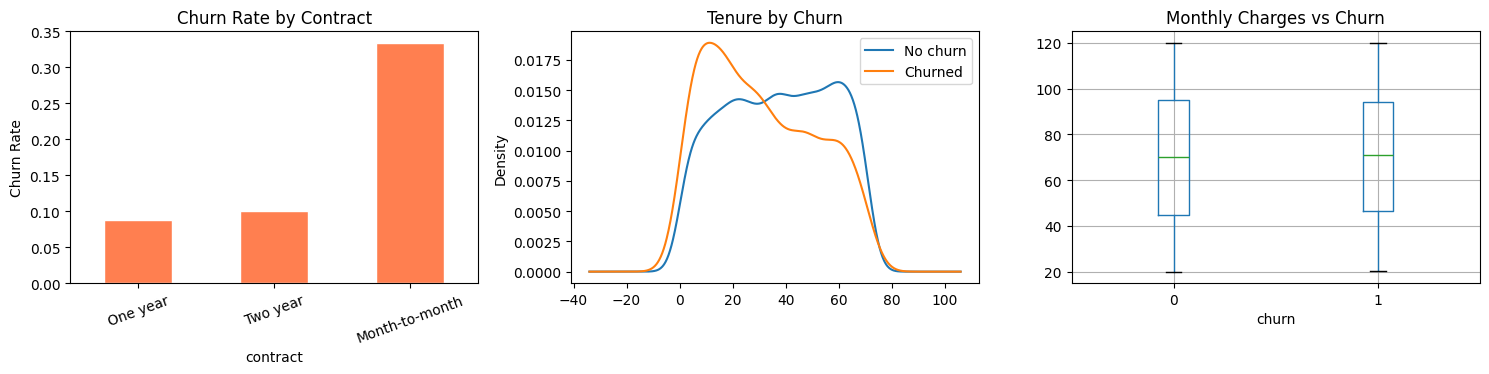

In [3]:
# visualize churn by contract type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('contract')['churn'].mean().sort_values().plot(
    kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Churn Rate by Contract')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=20)

df.groupby('churn')['tenure'].plot(kind='kde', ax=axes[1])
axes[1].set_title('Tenure by Churn')
axes[1].legend(['No churn', 'Churned'])

df.boxplot(column='monthly_charges', by='churn', ax=axes[2])
axes[2].set_title('Monthly Charges vs Churn')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [4]:
# encode categorical columns
le = LabelEncoder()
df['contract_enc'] = le.fit_transform(df['contract'])
df['internet_enc'] = le.fit_transform(df['internet'])

# drop original string columns
df_model = df.drop(['contract', 'internet'], axis=1)

# quick feature engineering
df_model['charges_per_product'] = df_model['monthly_charges'] / df_model['num_products']
df_model['calls_ratio'] = df_model['support_calls'] / df_model['tenure'].clip(lower=1)

X = df_model.drop('churn', axis=1)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(4000, 9) (1000, 9)


In [5]:
# gradient boosting works well for tabular data like this
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  max_depth=4, random_state=42)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

ROC-AUC: 0.6961

              precision    recall  f1-score   support

    Retained       0.79      0.95      0.86       779
     Churned       0.40      0.12      0.19       221

    accuracy                           0.77      1000
   macro avg       0.59      0.53      0.52      1000
weighted avg       0.70      0.77      0.71      1000



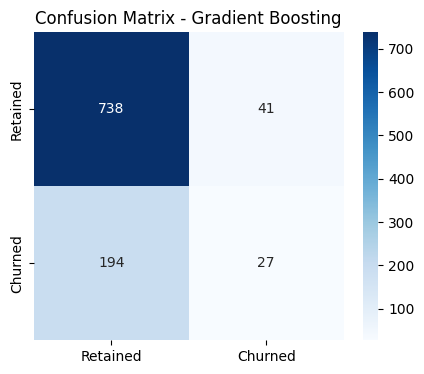

In [6]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

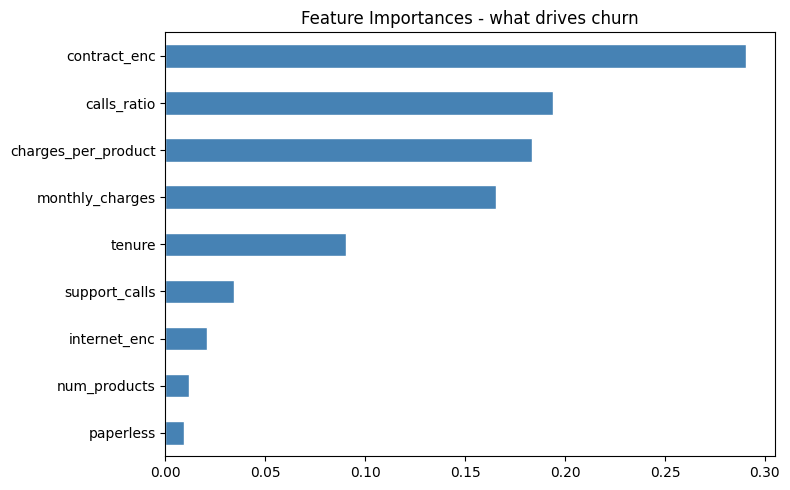

In [7]:
# feature importance - what's driving churn?
importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importances - what drives churn')
plt.tight_layout()
plt.show()